# Basic demonstration of fUSi analysis

This notebook shows the basic demonstration of analyzing audio data collected at UCLA


In [1]:
%load_ext autoreload
%autoreload 2

# import nilearn as nl
from nilearn import image
from nilearn.glm.first_level import make_first_level_design_matrix
from nilearn.plotting import plot_design_matrix

import nibabel as nib

import matplotlib.pyplot as plt
import numpy as np
from pathlib import Path

from ucla_doc_utils import DirectoryManager
import ucla_fusi_utils_audio as utils

In [2]:
base_path=Path('/Volumes/192.168.1.169/UCLA_collaboration/2024-06-13/UCLA_006/speech_stimulation')
sequence='seq-RF_5000000Hz_5a_3c_2rp_10Dmin_40Dmax_3el_TGC0ini_100end_1000Tdur_-1Gain_3AFE_200loops'

apply_image_registration=True # If true, we will register the fUSi data to the first frame. If false, we will not register the fUSi data.
smoothing_fwhm=.5 #0 spatial smoothing in mm to apply to the data before computing GLM
behavior_offset=4 # in seconds
num_locations=4 # How many ROIs to visualize


dm = DirectoryManager(base_path, sequence)
dm.list_acquisition_directories()
dm.print_paths()

/Volumes/192.168.1.169/UCLA_collaboration/2024-06-04/UCLA_005/speech_stimulation/acquisitions/seq-RF_5000000Hz_5a_3c_2rp_10Dmin_40Dmax_3el_TGC0ini_100end_1000Tdur_-1Gain_3AFE_200loops/fUSI
Directories in acquisitions path:
    seq-RF_5000000Hz_7a_3c_2rp_35Dmin_65Dmax_5el_TGC0ini_100end_1000Tdur_-1Gain_3AFE_200loops
    seq-RF_5000000Hz_5a_3c_2rp_10Dmin_40Dmax_3el_TGC0ini_100end_1000Tdur_-1Gain_3AFE_200loops
List of all directories in acquisitions path:
    log_file_path: /Volumes/192.168.1.169/UCLA_collaboration/2024-06-04/UCLA_005/speech_stimulation/logs/task_1.log
    task_event_file_path: /Volumes/192.168.1.169/UCLA_collaboration/2024-06-04/UCLA_005/speech_stimulation/streams/task_1-event_stream.h5
    probe_event_file_path: /Volumes/192.168.1.169/UCLA_collaboration/2024-06-04/UCLA_005/speech_stimulation/streams/probe_1-event_stream.h5
    sequence_data_path: /Volumes/192.168.1.169/UCLA_collaboration/2024-06-04/UCLA_005/speech_stimulation/acquisitions/seq-RF_5000000Hz_5a_3c_2rp_10Dm

In [3]:
# If beamforming and power doppler have not been performed, perform them using the following commands in your terminal (make sure mangrove is activated!)
# Command to execute the mangrove raw data to beamformed conversion
beamform_command =  f'python -m mangrove.io.convert.mangrove_raw_data_to_beamformed input_mode=experiments_root_folder input_mode.experiments_root_folder="{dm.sequence_data_path}"'
power_doppler_command =  f'python -m mangrove.io.convert.beamformed_to_doppler input_mode=experiments_root_folder input_mode.experiments_root_folder="{dm.sequence_data_path}"'

print(beamform_command)
print(power_doppler_command)

python -m mangrove.io.convert.mangrove_raw_data_to_beamformed input_mode=experiments_root_folder input_mode.experiments_root_folder="/Volumes/192.168.1.169/UCLA_collaboration/2024-06-04/UCLA_005/speech_stimulation/acquisitions/seq-RF_5000000Hz_5a_3c_2rp_10Dmin_40Dmax_3el_TGC0ini_100end_1000Tdur_-1Gain_3AFE_200loops"
python -m mangrove.io.convert.beamformed_to_doppler input_mode=experiments_root_folder input_mode.experiments_root_folder="/Volumes/192.168.1.169/UCLA_collaboration/2024-06-04/UCLA_005/speech_stimulation/acquisitions/seq-RF_5000000Hz_5a_3c_2rp_10Dmin_40Dmax_3el_TGC0ini_100end_1000Tdur_-1Gain_3AFE_200loops"


In [4]:
# load probe and task events
task_events = utils.extract_task_events(dm.task_event_file_path)
probe_events=utils.extract_probe_events(dm.probe_event_file_path)
task_events.onset=task_events.onset+behavior_offset

# process power doppler files
fusi_data, probe_events = utils.process_power_doppler_files(dm.power_doppler_path, 40, probe_events)

Filtered filenames: ['ensemble_2024-06-04T18-06-58-582839-pixel_size_wavelengths=0.5-num_blood_and_tissue_components=None_num_tissue_components=70.h5', 'ensemble_2024-06-04T18-20-24-339051-pixel_size_wavelengths=0.5-num_blood_and_tissue_components=None_num_tissue_components=70.h5', 'ensemble_2024-06-04T18-20-51-089688-pixel_size_wavelengths=0.5-num_blood_and_tissue_components=None_num_tissue_components=70.h5', 'ensemble_2024-06-04T18-25-16-946068-pixel_size_wavelengths=0.5-num_blood_and_tissue_components=None_num_tissue_components=70.h5', 'ensemble_2024-06-04T18-24-05-028913-pixel_size_wavelengths=0.5-num_blood_and_tissue_components=None_num_tissue_components=70.h5', 'ensemble_2024-06-04T18-15-18-312354-pixel_size_wavelengths=0.5-num_blood_and_tissue_components=None_num_tissue_components=70.h5', 'ensemble_2024-06-04T18-24-29-724394-pixel_size_wavelengths=0.5-num_blood_and_tissue_components=None_num_tissue_components=70.h5', 'ensemble_2024-06-04T18-21-37-647756-pixel_size_wavelengths=0.

In [5]:
print(probe_events)

              Event                           raw_file_name  acquisition_idx  \
0    ensemble_saved  ensemble_2024-06-04T18-05-40-533916.h5                0   
1    ensemble_saved  ensemble_2024-06-04T18-05-56-149077.h5                1   
2    ensemble_saved  ensemble_2024-06-04T18-05-58-354694.h5                2   
3    ensemble_saved  ensemble_2024-06-04T18-06-00-544455.h5                3   
4    ensemble_saved  ensemble_2024-06-04T18-06-02-754513.h5                4   
..              ...                                     ...              ...   
550  ensemble_saved  ensemble_2024-06-04T18-26-21-500827.h5              550   
551  ensemble_saved  ensemble_2024-06-04T18-26-23-709664.h5              551   
552  ensemble_saved  ensemble_2024-06-04T18-26-25-934080.h5              552   
553  ensemble_saved  ensemble_2024-06-04T18-26-28-133269.h5              553   
554  ensemble_saved  ensemble_2024-06-04T18-26-30-332848.h5              554   

      time_stamp                       

In [6]:
print(task_events)

                trial_type        onset   duration
0                  imagine    24.014217  29.161441
1        left_hand_squeeze    83.122221  29.905455
2                    still   134.593028  29.017557
3              descriptive   192.861536  27.505558
4                  silence   247.329326  29.953942
5       right_hand_squeeze   302.367182  28.849464
6   right_hand_squeeze_rev   353.024218  28.849646
7    left_hand_squeeze_rev   410.265803  29.905464
8    left_hand_squeeze_rev   469.323112  29.905534
9        left_hand_squeeze   523.952200  29.905495
10                 imagine   578.017692  29.161484
11  right_hand_squeeze_rev   631.522974  28.849529
12             descriptive   683.414162  27.505557
13                   still   739.170764  29.017576
14                 silence   790.177304  29.953897
15      right_hand_squeeze   841.250166  28.849523
16   left_hand_squeeze_rev   893.084351  29.905431
17                   still   950.435315  29.017470
18  right_hand_squeeze_rev   99

Convert the pandas data structure into something importable to nilearn


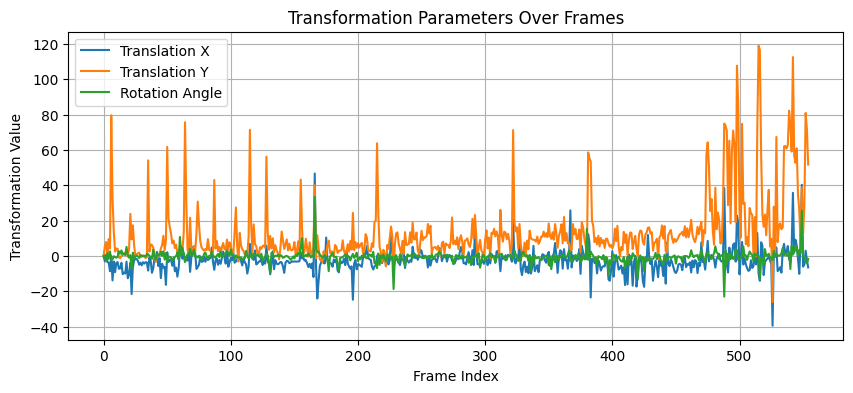

In [8]:
# perform image registration 
plot_transformations=True
if apply_image_registration:
    fusi_data_3d = fusi_data[:, 0, :, :]  # Keep only the first index of the second dimension
    # output_path=str(dm.fUSI_data_path/f"AcquisitionMovie_orig_{sequence}.png") 
    # video = utils.create_video_from_3d_data(fusi_data,output_path=output_path) # this was bugging, need to debug
    # fusi_data_3d=fusi_data_3d-np.min(fusi_data_3d)
    # fusi_data_3d=fusi_data_3d/np.max(fusi_data_3d) *256
    # fusi_data_3d_reg,transformations, metric_value =utils.register_phase_corr(fusi_data_3d)
    fusi_data_3d_reg,transformations=utils.register_ants(fusi_data_3d)
    # Reintroduce the second dimension and tile the data
    fusi_data_3d_reg_expanded = np.expand_dims(fusi_data_3d_reg, axis=1)  # Add a singleton dimension at axis 1
    # output_path=str(dm.fUSI_data_path/f"AcquisitionMovie_reg_{sequence}.png")
    # video = utils.create_video_from_3d_data(fusi_data,output_path=output_path)
    # display(video)
    fusi_data = np.tile(fusi_data_3d_reg_expanded, (1, 2, 1, 1))
    if plot_transformations:
        plt.figure(figsize=(10, 4))
        plt.plot(transformations[0, :], label='Translation X')
        plt.plot(transformations[1, :], label='Translation Y')
        plt.plot(transformations[2, :]*180/np.pi, label='Rotation Angle')

        
        plt.title('Transformation Parameters Over Frames')
        plt.xlabel('Frame Index')
        plt.ylabel('Transformation Value')
        plt.legend()
        plt.grid(True)
        plt.show()


/var/folders/gk/zbxjhf5j6h7bvyv252qq64s40000gn/T/ipykernel_35046/902830363.py:23: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



<Figure size 640x480 with 0 Axes>

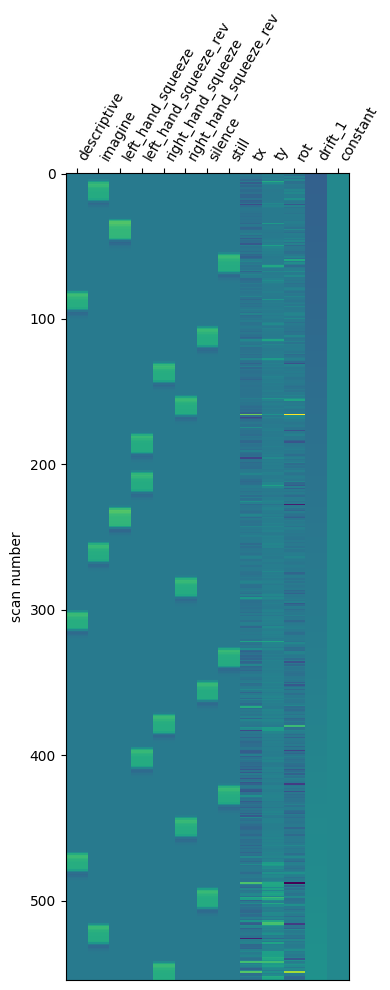

In [9]:

hrf_model = "glover"
if apply_image_registration:
    design_matrix = make_first_level_design_matrix(
        probe_events['time_stamp'] ,
        task_events,
        drift_model="polynomial",
        drift_order=1,
        add_regs=transformations.transpose(),
        add_reg_names=["tx","ty","rot"],
        hrf_model=hrf_model,
    )
else:
    design_matrix = make_first_level_design_matrix(
        probe_events['time_stamp'] ,
        task_events,
        drift_model="polynomial",
        drift_order=1,
        hrf_model=hrf_model,
    )

fig = plt.figure()
plot_design_matrix(design_matrix)
fig.show()



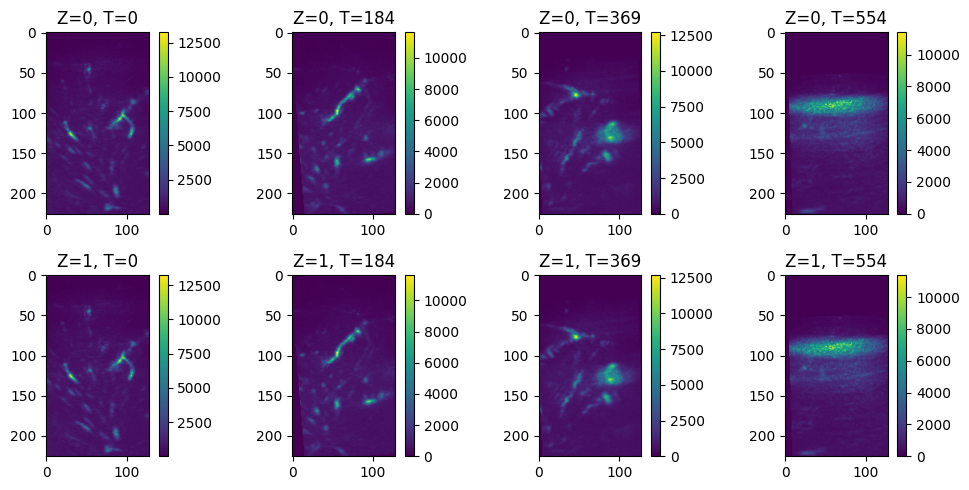

In [10]:
# Plot the data, make sure nothing crazy is happening, in particular, as I am mocking a 3D scan to play nice with nilearn, we need to make sure the data is in the right shape and the info across the second dimension is simply a copy
import matplotlib.pyplot as plt
# visualize to ensure we are getting what we think we should be getting!

fig, axs = plt.subplots(nrows=2, ncols=4, figsize=(10, 5))  # 2 rows for Z dimension, 4 columns for T dimension
for z_dim in range(2):  # Loop over the Z dimension (1 dimension)
    for t_index, t_dim in enumerate(np.linspace(0, fusi_data.shape[3] - 1, 4, dtype=int)):  # Sample 4 equally spaced indices along the T dimension
        ax = axs[z_dim, t_index]
        img_plot = ax.imshow(np.flip(fusi_data[:, z_dim, :, t_dim].transpose(), axis=0), aspect='equal')
        ax.set_title(f'Z={z_dim}, T={t_dim}')
        plt.colorbar(img_plot, ax=ax)

plt.tight_layout()
plt.show()

In [11]:
from nilearn.signal import butterworth


affine=np.diag([.15,.15,.15,0])
# pd=np.array(fusi_data)
def boxcar_smooth(data, window_size):
    if window_size>0:
        smoothed_data = np.copy(data)
        for t in range(data.shape[3]):
            start_index = max(0, t - window_size // 2)
            end_index = min(data.shape[3], t + window_size // 2 + 1)
            smoothed_data[:, :, :, t] = np.mean(data[:, :, :, start_index:end_index], axis=3)
    else:
        smoothed_data=data
    return smoothed_data

window_size = 0  # Number of time points for smoothing
pd = boxcar_smooth(fusi_data, window_size)
nifti_img = nib.Nifti1Image(pd, affine)
nifti_img.to_filename(dm.fUSI_data_path/"fUSi_data.nii.gz")
nifti_data=image.load_img(dm.fUSI_data_path/"fUSi_data.nii.gz")
nifti_data.shape

(128, 2, 226, 555)

In [12]:
contrast_matrix = np.eye(design_matrix.shape[1])
basic_contrasts = {
    column: contrast_matrix[i]
    for i, column in enumerate(design_matrix.columns)
}
basic_contrasts

{'descriptive': array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 'imagine': array([0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 'left_hand_squeeze': array([0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 'left_hand_squeeze_rev': array([0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 'right_hand_squeeze': array([0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]),
 'right_hand_squeeze_rev': array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.]),
 'silence': array([0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.]),
 'still': array([0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.]),
 'tx': array([0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.]),
 'ty': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.]),
 'rot': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.]),
 'drift_1': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.]),
 'constant': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.])}

In [13]:
from nilearn.glm.first_level import FirstLevelModel

print("Fitting a GLM")
fmri_glm = FirstLevelModel(minimize_memory=False,mask_img=False,smoothing_fwhm=smoothing_fwhm,standardize=True)
fmri_glm = fmri_glm.fit(nifti_data, design_matrices=design_matrix)

Fitting a GLM


Computing contrasts
	contrast id: descriptive


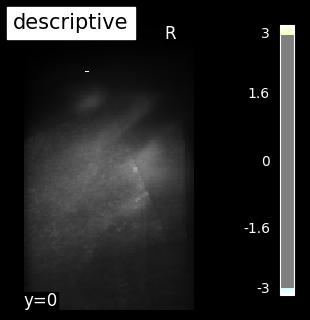

	contrast id: imagine


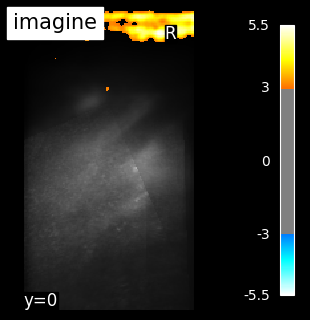

	contrast id: left_hand_squeeze


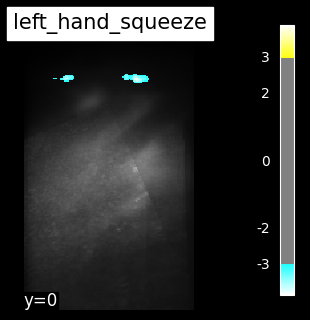

	contrast id: left_hand_squeeze_rev


/Users/taflalo/miniconda3/envs/Anise/lib/python3.9/site-packages/nilearn/plotting/displays/_slicers.py:308: UserWarning:

empty mask



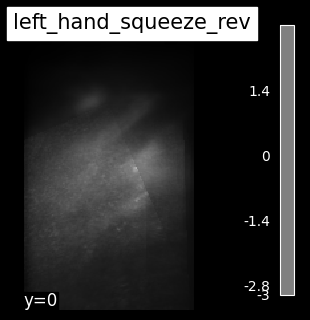

	contrast id: right_hand_squeeze


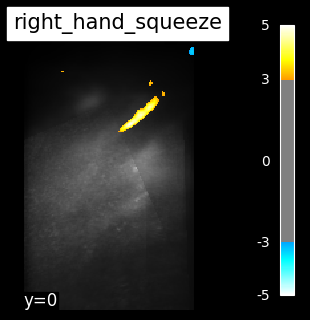

	contrast id: right_hand_squeeze_rev


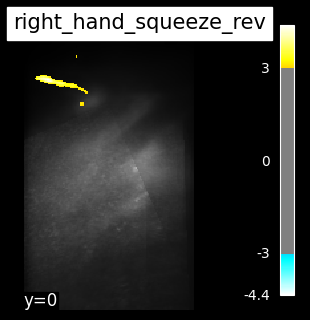

	contrast id: silence


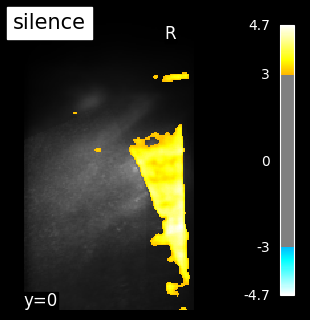

	contrast id: still


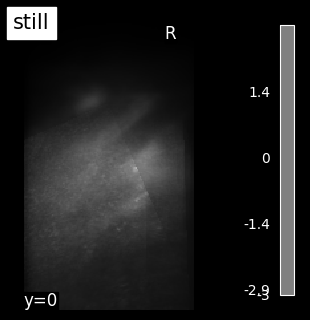

	contrast id: tx


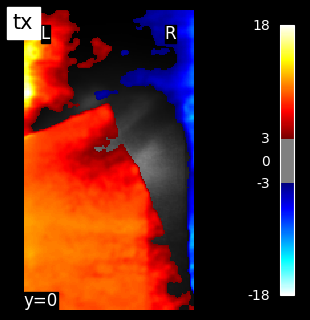

	contrast id: ty


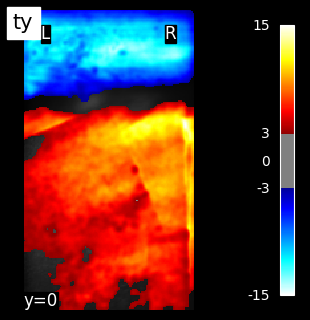

	contrast id: rot


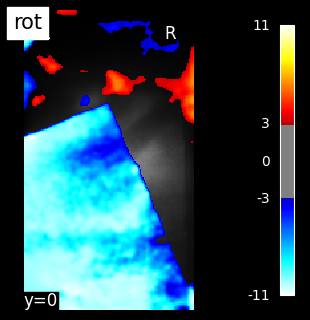

	contrast id: drift_1


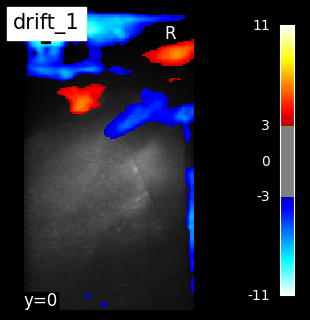

	contrast id: constant


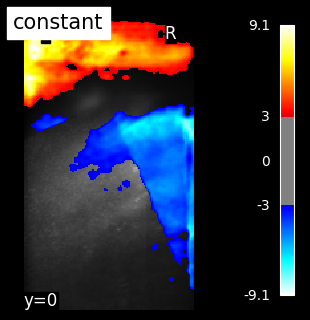

In [14]:
from nilearn import plotting
from nilearn.image import concat_imgs, mean_img, resample_img

print("Computing contrasts")

mean_image = mean_img(nifti_data)
# Iterate on contrasts
for contrast_id, contrast_val in basic_contrasts.items():
    print(f"\tcontrast id: {contrast_id}")
    # compute the contrasts
    z_map = fmri_glm.compute_contrast(contrast_val, output_type="stat") # 
    # plot the contrasts as soon as they're generated
    # the display is overlaid on the mean fMRI image
    # a threshold of 3.0 is used, more sophisticated choices are possible
    plotting.plot_stat_map(
        z_map,
        bg_img=mean_image,
        threshold=3,        
        cut_coords=[0],
        display_mode="y",        
        black_bg=True,        
        title=contrast_id,
    )
    plotting.show()

# Plot time series for ROI response and stimulus regressor

Identify ROIs using an automated clustering approach. Extract the time series for each ROI. Plot the time series and corresponding locations.



In [15]:
basic_contrasts


{'descriptive': array([1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 'imagine': array([0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 'left_hand_squeeze': array([0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 'left_hand_squeeze_rev': array([0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.]),
 'right_hand_squeeze': array([0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]),
 'right_hand_squeeze_rev': array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0.]),
 'silence': array([0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0.]),
 'still': array([0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0.]),
 'tx': array([0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0.]),
 'ty': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0.]),
 'rot': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0.]),
 'drift_1': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1., 0.]),
 'constant': array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.])}

In [16]:
from nilearn.maskers import NiftiSpheresMasker
from nilearn.reporting import get_clusters_table

contrast_to_plot = 'descriptive'
stat_threshold=1

# Find ROIs by identifying the locations that show a significant response to the stimulus
mean_image = mean_img(nifti_data)
z_map = fmri_glm.compute_contrast(basic_contrasts[contrast_to_plot], output_type="stat")
# z_map = fmri_glm.compute_contrast(basic_contrasts['drift_1'], output_type="stat")
table = get_clusters_table(z_map, stat_threshold=stat_threshold, cluster_threshold=20)
table.set_index("Cluster ID", drop=True)
table.head()

# get the num_locations largest clusters' max x, y, and z coordinates
coords = table.loc[range(0, num_locations), ["X", "Y", "Z"]].values
coords = np.vstack([coords, [10.45000061,  0.        , 18.40000045]])

# Now use the ROIs to extract the time series 
masker = NiftiSpheresMasker(coords)
standardize="zscore" # zscore psc
masker = NiftiSpheresMasker(
    coords,
    radius=.5,
    detrend=True,
    standardize=standardize, # zscore psc
    # low_pass=0.1,
    # high_pass=0.01,
    t_r=3.5,
    # memory="nilearn_cache",
    memory_level=1,
    verbose=0,
)

real_timeseries = masker.fit_transform(nifti_data)
# predicted_timeseries = masker.fit_transform(fmri_glm.predicted[0])
predicted_timeseries = np.tile(design_matrix[contrast_to_plot].values, (real_timeseries.shape[1], 1)).T


In [17]:
from sklearn.metrics import r2_score

# Calculate the R-squared value for each ROI
r_squared_values = []
for i in range(real_timeseries.shape[1]):
    r_squared = r2_score(real_timeseries[:, i], predicted_timeseries[:, i])
    r_squared_values.append(r_squared)

# Display the R-squared values
print("R-squared values for each ROI:")
for idx, r2 in enumerate(r_squared_values):
    print(f"ROI {idx + 1}: {r2:.3f}")


R-squared values for each ROI:
ROI 1: -0.009
ROI 2: 0.017
ROI 3: -0.009
ROI 4: -0.030
ROI 5: -0.073


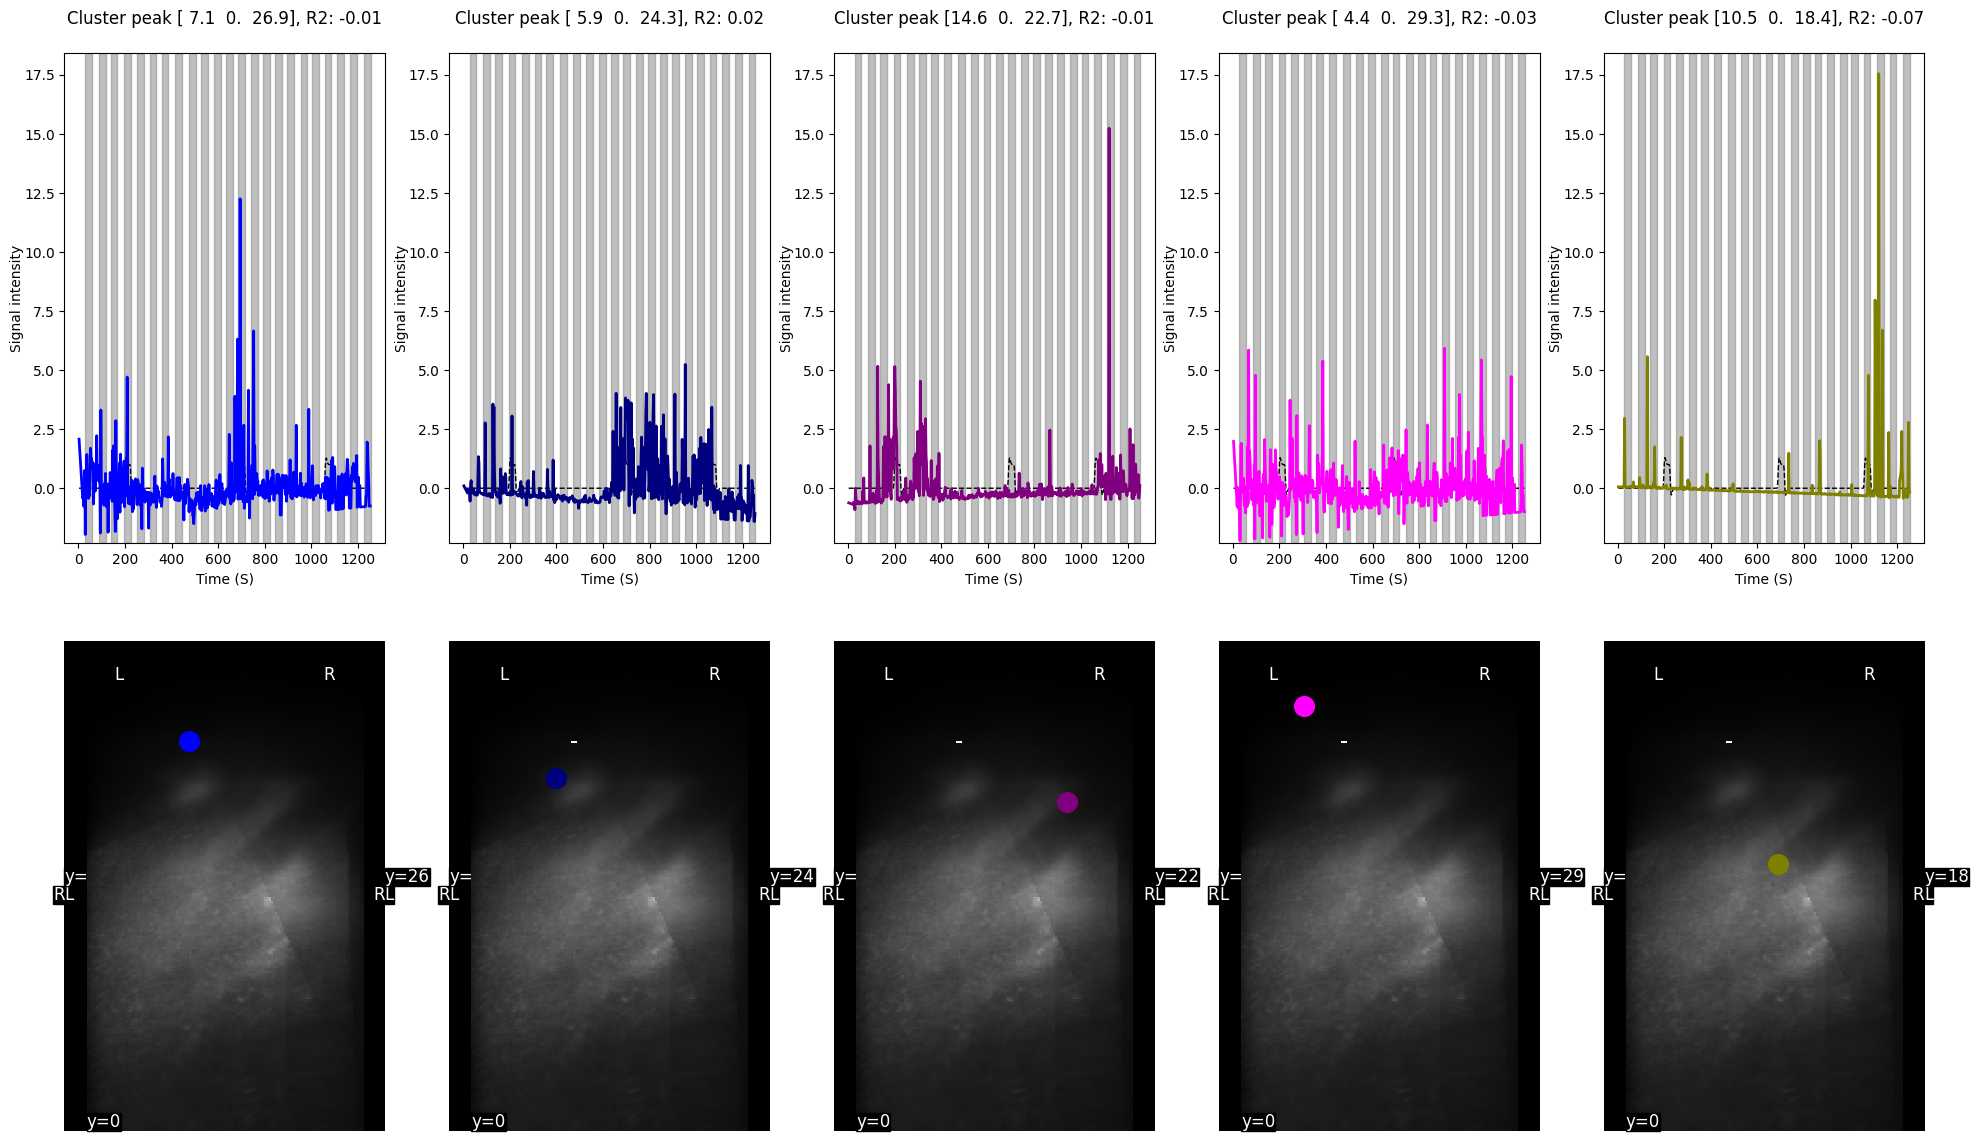

In [18]:
# And finaly, plot the time series for each ROI and the corresponding location of each ROI
# colors for each of the clusters
colors = ["blue", "navy", "purple", "magenta", "olive", "teal"]
# plot the time series and corresponding locations
N=real_timeseries.shape[-1]
fig1, axs1 = plt.subplots(2, N)

# get plot limits, common across all axis
mx=real_timeseries.max()+0.05*real_timeseries.max()
mn=real_timeseries.min()+0.05*real_timeseries.min()

for i in range(N):
    # plotting time series
    axs1[0, i].set_title(f"Cluster peak {coords[i].round(1)}, R2: {r_squared_values[i]:.2f}\n")
    if masker.standardize != "psc":
        axs1[0, i].plot(probe_events['time_stamp'], predicted_timeseries[:, i], c="k", ls="--", lw=1)
    # axs1[0, i].plot(fusi_info['Experiment Time'], predicted_timeseries[:, i], c="k", ls="--", lw=1)
    # axs1[0, i].plot(fusi_info['Experiment Time'], design_matrix['Stimulus on'], c="k", ls="--", lw=1)
    axs1[0, i].plot(probe_events['time_stamp'], real_timeseries[:, i], c=colors[i], lw=2)
    axs1[0, i].set_xlabel("Time (S)")

    if masker.standardize == "psc":
        axs1[0, i].set_ylabel('Percent Signal Change', labelpad=0)
    else:
        axs1[0, i].set_ylabel("Signal intensity", labelpad=0)

    # plotting image below the time series
    # Highlight regions of time described by the onsets and durations in events
    # Assuming 'events' is a DataFrame with columns 'onset' and 'duration' for stimulus events
    for onset, duration in zip(task_events['onset'], task_events['duration']):
        axs1[0, i].axvspan(onset+behavior_offset, onset + duration+behavior_offset, color='gray', alpha=0.5)
    
    roi_img = plotting.plot_stat_map(
        z_map,
        cut_coords=coords[i],
        threshold=3,
        figure=fig1,
        axes=axs1[1, i],
        display_mode="y",
        colorbar=False,
        bg_img=mean_image,
    )
    
    axs1[0, i].set_ylim(mn, mx)
    roi_img.add_markers([coords[i]], colors[i], 200)
fig1.set_size_inches(24, 14)

# fig1.savefig(dm.fUSI_data_path/f"ROI_time_series_{sequence}.png")



In [19]:
fig1.savefig(dm.fUSI_data_path/f"ROI_time_series_{sequence}.svg")

In [20]:

# num_tissue_components=30
# import os
# import re

# filenames = [f for f in os.listdir(dm.power_doppler_path) if f.endswith('.h5')]

# if not filenames:
#     raise ValueError("No power doppler files found in the specified directory.")


# # Extract unique values of num_tissue_components from filenames
# unique_tissue_components = set(re.findall(r'num_tissue_components=(\d+)', ' '.join(filenames)))


# # Check if the desired num_tissue_components is in the unique set of tissue components available in filenames
# if str(num_tissue_components) in unique_tissue_components:
#     # Filter filenames to include only those with 'num_tissue_components=N' where N is the number of tissue components
#     filtered_filenames = [f for f in filenames if f'num_tissue_components={num_tissue_components}' in f]
#     print("Filtered filenames:", filtered_filenames)
# else:
#     # Find the closest available num_tissue_components if the desired one is not available
#     closest_num_tissue_components = min(unique_tissue_components, key=lambda x: abs(int(x) - num_tissue_components))
#     filtered_filenames = [f for f in filenames if f'num_tissue_components={closest_num_tissue_components}' in f]
#     print(f"Warning: num_tissue_components={num_tissue_components} is not available. Using closest available value: {closest_num_tissue_components}")
#     print("Filtered filenames:", filtered_filenames)

# # for each probe event, make sure there is a corresponding processed power doppler file
# def match_and_add_fusi_filenames(probe_events, filtered_filenames):
#     # Create a new column in probe_events to store the matched filenames from filtered_filenames
#     probe_events['fusi_file_name'] = ''

#     # Iterate through each row in probe_events
#     for index, row in probe_events.iterrows():
#         # Extract the filename from the current row in probe_events
#         probe_filename = row['raw_file_name']
#         # print(probe_filename[0:-3])
#         # Check if this filename exists in the filtered_filenames list
#         matched_filenames = [filename for filename in filtered_filenames if probe_filename[0:-3] in filename]

#         # If there is a match, add the filename to the new column
#         if matched_filenames:
#             probe_events.at[index, 'fusi_file_name'] = matched_filenames[0]
    
#     return probe_events
# # Call the function to match and add filenames
# match_and_add_fusi_filenames(probe_events, filtered_filenames)

# # Check if every entry in 'fusi_file_name' column is populated
# if probe_events['fusi_file_name'].isnull().any():
#     raise ValueError("Some entries in 'fusi_file_name' are not populated.")
# else:
#     print("All entries in 'fusi_file_name' are properly populated.")

# import h5py
# def get_fusi_frames(power_doppler_path, probe_events, frame_indices=-1):
#     """
#     Fetches the data from specific frames in the h5 files based on the list of frame indices.
    
#     Args:
#     power_doppler_path (str): The directory where the h5 files are stored.
#     probe_events (DataFrame): DataFrame containing the filenames and timestamps.
#     frame_indices (list of int): The indices of the frames to fetch.
    
#     Returns:
#     np.array: The data from the specified frames in the h5 files, stacked along the last dimension.
#     """
#     # Check if all frame_indices are valid
#     if frame_indices == -1:
#         frame_indices = list(range(len(probe_events)))
#     elif any(frame_index < 0 or frame_index >= len(probe_events) for frame_index in frame_indices):
#         raise ValueError("One or more invalid frame indices")
    
#     # Initialize a list to hold the data arrays
#     data_list = []
    
#     for frame_index in frame_indices:
#         # Get the filename for the desired frame
#         filename = probe_events.iloc[frame_index]['fusi_file_name']
#         file_path = os.path.join(power_doppler_path, filename)

#         # Load the h5 file
#         with h5py.File(file_path, 'r') as file:
#             # Assuming the dataset name in the h5 file is 'beamformed'
#             try:
#                 data = file['beamformed'][:]
#             except KeyError:
#                 data = file['power_doppler'][:]
#             data_list.append(data)
    
#     # Stack the data arrays along the last dimension
#     stacked_data = np.stack(data_list, axis=-1)
    
#     N=2
#     frames_data_replicated = np.tile(stacked_data, (1, N, 1, 1))
#     frames_data_replicated = np.flip(frames_data_replicated, axis=2) # get in the right coordinate system

#     return frames_data_replicated

# fusi_data = get_fusi_frames(dm.power_doppler_path, probe_events)

